# AI Lab: Solving Problems by Searching & Knowledge Representation

**Name:** Charite Uwatwembi  
**Andrew ID:** cuwatwem  
**Date:** 14 September 2026

**Based on:** Russell & Norvig, *Artificial Intelligence: A Modern Approach*
- Chapter 3 — Solving Problems by Searching
- Foundational graph theory that underlies search: connectivity, cycles, and spanning trees

**Reference implementation:** this lab is inspired by the `search.ipynb` notebook from
[`aimacode/aima-python`](https://github.com/aimacode/aima-python/tree/master/notebooks), but is
rewritten as a **self-contained lab** — no external `aima` package required, just the Python
standard library plus `networkx`/`matplotlib` for the visualizations.

## How this lab works
- Each section gives you some **starter code** (already working, read it before you use it).
- Each `# TODO` cell asks you to complete a function. Run the cell below it to sanity-check your work.
- Each **Question** markdown cell asks you to write 2–4 sentences demonstrating you understood
  *why* the algorithm behaves the way it did, not just that your code produced the right output.

There are two parts:
1. **Part 1 — Search**: uninformed search (BFS, DFS, UCS) and informed search (Greedy Best-First, A\*)
   on the classic Romania road-map problem (AIMA Figure 3.2).
2. **Part 2 — Graph Theory**: the structural properties of a graph that search relies on —
   degree and the handshake lemma, connectivity, connected components, cycle detection, and
   Eulerian/Hamiltonian circuits.


In [1]:
# Setup — run this first
import heapq
import math
from collections import deque, defaultdict

import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline


---
# Part 1: Search

## 1.1 Representing a search problem

AIMA formalizes search around a few core ideas:

- A **problem** has an initial state, a set of actions available in each state, a transition
  model (`result`), a goal test, and a path cost function.
- A **node** in the search tree wraps a state together with the path that reached it (its parent,
  the action taken, and the accumulated cost).

The classes below are the standard scaffolding — read through them, but you don't need to modify
them. All of your work in Part 1 is in implementing the **search algorithms** further down.


In [2]:
class Graph:
    """A weighted graph, stored as {node: {neighbor: distance, ...}, ...}.
    Undirected by default: an edge A-B is automatically mirrored as B-A."""

    def __init__(self, graph_dict=None, directed=False):
        self.graph_dict = graph_dict or {}
        self.directed = directed
        if not directed:
            self._make_undirected()

    def _make_undirected(self):
        for a in list(self.graph_dict.keys()):
            for b, dist in list(self.graph_dict[a].items()):
                self.graph_dict.setdefault(b, {})[a] = dist

    def get(self, a, b=None):
        neighbors = self.graph_dict.setdefault(a, {})
        return neighbors if b is None else neighbors.get(b)

    def nodes(self):
        return list(self.graph_dict.keys())


# The Romania road map from AIMA Figure 3.2
romania_map = Graph(dict(
    Arad=dict(Zerind=75, Sibiu=140, Timisoara=118),
    Bucharest=dict(Urziceni=85, Pitesti=101, Giurgiu=90, Fagaras=211),
    Craiova=dict(Drobeta=120, Rimnicu=146, Pitesti=138),
    Drobeta=dict(Mehadia=75),
    Eforie=dict(Hirsova=86),
    Fagaras=dict(Sibiu=99),
    Hirsova=dict(Urziceni=98),
    Iasi=dict(Vaslui=92, Neamt=87),
    Lugoj=dict(Timisoara=111, Mehadia=70),
    Oradea=dict(Zerind=71, Sibiu=151),
    Pitesti=dict(Rimnicu=97),
    Rimnicu=dict(Sibiu=80),
    Urziceni=dict(Vaslui=142)))

# Straight-line distance to Bucharest, AIMA Figure 3.22 (used as a heuristic later)
sld_to_bucharest = dict(
    Arad=366, Bucharest=0, Craiova=160, Drobeta=242, Eforie=161,
    Fagaras=176, Giurgiu=77, Hirsova=151, Iasi=226, Lugoj=244,
    Mehadia=241, Neamt=234, Oradea=380, Pitesti=100, Rimnicu=193,
    Sibiu=253, Timisoara=329, Urziceni=80, Vaslui=199, Zerind=374)


class Problem:
    """Abstract search problem. Subclass and override actions/result/goal_test/path_cost."""

    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        raise NotImplementedError

    def result(self, state, action):
        raise NotImplementedError

    def goal_test(self, state):
        return state == self.goal

    def path_cost(self, c, state1, action, state2):
        return c + 1


class GraphProblem(Problem):
    """A problem for finding a route on a Graph, e.g. driving from Arad to Bucharest."""

    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return list(self.graph.get(state).keys())

    def result(self, state, action):
        return action  # in a road map, the action IS the destination city

    def path_cost(self, c, state1, action, state2):
        return c + (self.graph.get(state1, state2) or 1)

    def h(self, state):
        """Straight-line-distance heuristic to Bucharest."""
        return sld_to_bucharest.get(state, 0)


class Node:
    """A node in a search tree: a state plus a pointer back to its parent."""

    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.depth = 0 if parent is None else parent.depth + 1

    def path(self):
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

    def solution(self):
        """The sequence of states from the root to this node."""
        return [n.state for n in self.path()]

    def expand(self, problem):
        """List the nodes reachable in one step from this node."""
        children = []
        for action in problem.actions(self.state):
            next_state = problem.result(self.state, action)
            cost = problem.path_cost(self.path_cost, self.state, action, next_state)
            children.append(Node(next_state, self, action, cost))
        return children

    def __repr__(self):
        return f"<Node {self.state}>"

    def __lt__(self, other):
        # Lets Node break ties safely inside a heapq
        return self.path_cost < other.path_cost


romania_problem = GraphProblem('Arad', 'Bucharest', romania_map)
print("Problem: drive from", romania_problem.initial, "to", romania_problem.goal)


Problem: drive from Arad to Bucharest


## 1.2 Uninformed search: Breadth-First Search

Implement **graph-search** BFS: it should explore the frontier in FIFO order and keep an
`explored` set of states so it never expands the same state twice.

Return the goal `Node` if found (so the caller can call `.solution()` / `.path_cost` on it),
or `None` if the goal is unreachable.


In [3]:
def breadth_first_search(problem):
    """Find a route with the fewest steps."""
    node = Node(problem.initial)
    if problem.goal_test(node.state):
        return node

    frontier = deque([node])
    explored = {node.state}

    while frontier:
        node = frontier.popleft()  # Take the oldest city in the queue.
        for child in node.expand(problem):
            if child.state not in explored:
                if problem.goal_test(child.state):
                    return child
                # Remember the city when adding it, so it is not added twice.
                explored.add(child.state)
                frontier.append(child)

    return None


In [4]:
bfs_result = breadth_first_search(romania_problem)
print("BFS path: ", bfs_result.solution())
print("BFS cost: ", bfs_result.path_cost)


BFS path:  ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
BFS cost:  450


**Q1.** Why does graph-search BFS need an `explored` set (tree-search doesn't use one)?
Concretely, what would go wrong on the Romania map if you removed it?

**Answer:** The explored set stops BFS from adding and expanding the same city again and again. Without it, a route such as Arad to Zerind to Arad would bring the search back to a city it has already seen and create repeated work. BFS can still reach Bucharest, but it would waste more time and memory; if the goal were unreachable, cycles could keep the search running forever.

## 1.3 Uninformed search: Depth-First Search

Implement graph-search DFS. Use a **stack** (LIFO) for the frontier this time, and only check
`goal_test` when you *pop* a node (not when you generate it) — that's the standard DFS formulation.


In [5]:
def depth_first_search(problem):
    """Follow one branch as far as possible before trying another."""
    frontier = [Node(problem.initial)]
    explored = set()

    while frontier:
        node = frontier.pop()  # Take the newest city from the stack.
        if problem.goal_test(node.state):
            return node

        if node.state not in explored:
            explored.add(node.state)
            for child in node.expand(problem):
                if child.state not in explored:
                    frontier.append(child)

    return None


In [6]:
dfs_result = depth_first_search(romania_problem)
print("DFS path: ", dfs_result.solution())
print("DFS cost: ", dfs_result.path_cost)


DFS path:  ['Arad', 'Timisoara', 'Lugoj', 'Mehadia', 'Drobeta', 'Craiova', 'Pitesti', 'Bucharest']
DFS cost:  733


**Q2.** Compare the BFS and DFS results above: paths found and their costs. Neither
algorithm looks at edge weights while searching. Which one happened to find the cheaper path here,
and is that something you should rely on in general? Why or why not?

**Answer:** BFS found Arad → Sibiu → Fagaras → Bucharest, with a total distance of 450 km. DFS found Arad → Timisoara → Lugoj → Mehadia → Drobeta → Craiova → Pitesti → Bucharest, with a total distance of 733 km. BFS happened to find the cheaper route here, but it only aims for the fewest roads, while DFS follows the stack order. I would not rely on either one to find the shortest total distance because neither uses road distances to choose which route to try next.

## 1.4 Uninformed search: Uniform-Cost Search

UCS fixes the problem from Q2 by always expanding the frontier node with the **lowest path cost
g(n)** first, using a priority queue instead of a FIFO/stack.


In [7]:
def uniform_cost_search(problem):
    """Try the route with the lowest distance travelled so far."""
    start = Node(problem.initial)
    frontier = [(0, 0, start)]
    counter = 0
    best_cost = {start.state: 0}

    while frontier:
        cost, _, node = heapq.heappop(frontier)
        # Ignore an old entry if a cheaper route to this city was found.
        if cost > best_cost[node.state]:
            continue
        if problem.goal_test(node.state):
            return node

        for child in node.expand(problem):
            if child.path_cost < best_cost.get(child.state, math.inf):
                best_cost[child.state] = child.path_cost
                counter += 1  # Give tied costs a clear order.
                heapq.heappush(frontier, (child.path_cost, counter, child))

    return None


In [8]:
ucs_result = uniform_cost_search(romania_problem)
print("UCS path: ", ucs_result.solution())
print("UCS cost: ", ucs_result.path_cost)


UCS path:  ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']
UCS cost:  418


**Q3.** Is UCS guaranteed to find the optimal (lowest-cost) path on this map? What
assumption about edge/step costs does that guarantee depend on?

**Answer:** Yes, UCS is guaranteed to find the cheapest route on this map because every road has a positive distance. It always takes the lowest total cost from the priority queue and accepts the goal only when it removes that goal from the queue. The guarantee depends on having no negative road costs, which could make a route cheaper after it has already been considered.

## 1.5 Informed search: Greedy Best-First Search and A\*

Both algorithms use a **heuristic** `h(n)` — an estimate of the cost from `n` to the goal.
Greedy best-first search expands the node that *looks* closest to the goal (`h(n)` only);
A\* balances that against the cost already paid to get there (`f(n) = g(n) + h(n)`).

`GraphProblem.h(state)` (defined above) already implements the straight-line-distance heuristic
from AIMA Figure 3.22, so you can use `problem.h` directly below.


In [9]:
def greedy_best_first_search(problem, h):
    """Try the city that seems closest to the goal."""
    start = Node(problem.initial)
    frontier = [(h(start.state), 0, start)]
    counter = 0
    explored = set()

    while frontier:
        _, _, node = heapq.heappop(frontier)
        if node.state in explored:
            continue
        if problem.goal_test(node.state):
            return node

        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored:
                counter += 1
                # The priority uses only the estimated distance left.
                heapq.heappush(frontier, (h(child.state), counter, child))

    return None


In [10]:
greedy_result = greedy_best_first_search(romania_problem, romania_problem.h)
print("Greedy path: ", greedy_result.solution())
print("Greedy cost: ", greedy_result.path_cost)


Greedy path:  ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Greedy cost:  450


**Q4.** Greedy best-first search is *not* guaranteed to be optimal. Compare its path/cost
above to UCS's. Explain, in terms of what information greedy search ignores, why it can be led
astray.

**Answer:** Greedy search found Arad → Sibiu → Fagaras → Bucharest at 450 km, while UCS found Arad → Sibiu → Rimnicu → Pitesti → Bucharest at 418 km. Greedy search only uses the estimated distance left and ignores the cost already paid to reach a city. At Sibiu, Fagaras looks closer to Bucharest than Rimnicu does, but the road from Fagaras to Bucharest is long, so this choice gives a more expensive route.

In [11]:
def astar_search(problem, h):
    """Use distance already travelled plus estimated distance left."""
    start = Node(problem.initial)
    frontier = [(start.path_cost + h(start.state), 0, start)]
    counter = 0
    best_cost = {start.state: 0}

    while frontier:
        _, _, node = heapq.heappop(frontier)
        if node.path_cost > best_cost[node.state]:
            continue
        if problem.goal_test(node.state):
            return node

        for child in node.expand(problem):
            if child.path_cost < best_cost.get(child.state, math.inf):
                best_cost[child.state] = child.path_cost
                counter += 1
                priority = child.path_cost + h(child.state)
                heapq.heappush(frontier, (priority, counter, child))

    return None


In [12]:
astar_result = astar_search(romania_problem, romania_problem.h)
print("A* path: ", astar_result.solution())
print("A* cost: ", astar_result.path_cost)


A* path:  ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']
A* cost:  418


**Q5.** A\* with an *admissible* heuristic (one that never overestimates the true remaining
cost) is guaranteed to find the optimal solution. In your own words, explain why combining `g(n)`
and `h(n)` fixes the problem you described in Q4 — and check: is straight-line distance an
admissible heuristic for a road map? Why?

**Answer:** A* adds the cost already travelled, `g(n)`, to the estimated cost still left, `h(n)`, so a city looking close to Bucharest is not enough on its own to make a route look best. Unlike greedy search, it also accounts for the distance spent getting there, and it found the same 418 km route as UCS. Straight-line distance is admissible because the direct distance between two cities cannot be longer than the road route connecting them. This estimate therefore does not overstate the remaining driving distance.

### Search results at a glance

These results use the neighbor order in the supplied notebook.

| Algorithm | Route | Roads used | Distance (km) |
| --- | --- | --- | --- |
| BFS | Arad → Sibiu → Fagaras → Bucharest | 3 | 450 |
| DFS | Arad → Timisoara → Lugoj → Mehadia → Drobeta → Craiova → Pitesti → Bucharest | 7 | 733 |
| UCS | Arad → Sibiu → Rimnicu → Pitesti → Bucharest | 4 | 418 |
| Greedy | Arad → Sibiu → Fagaras → Bucharest | 3 | 450 |
| A* | Arad → Sibiu → Rimnicu → Pitesti → Bucharest | 4 | 418 |

I am comparing total road distance, not just the number of roads in a route.

## 1.6 Visualize the map and the optimal path

Draw the Romania map and highlight the path A\* found.


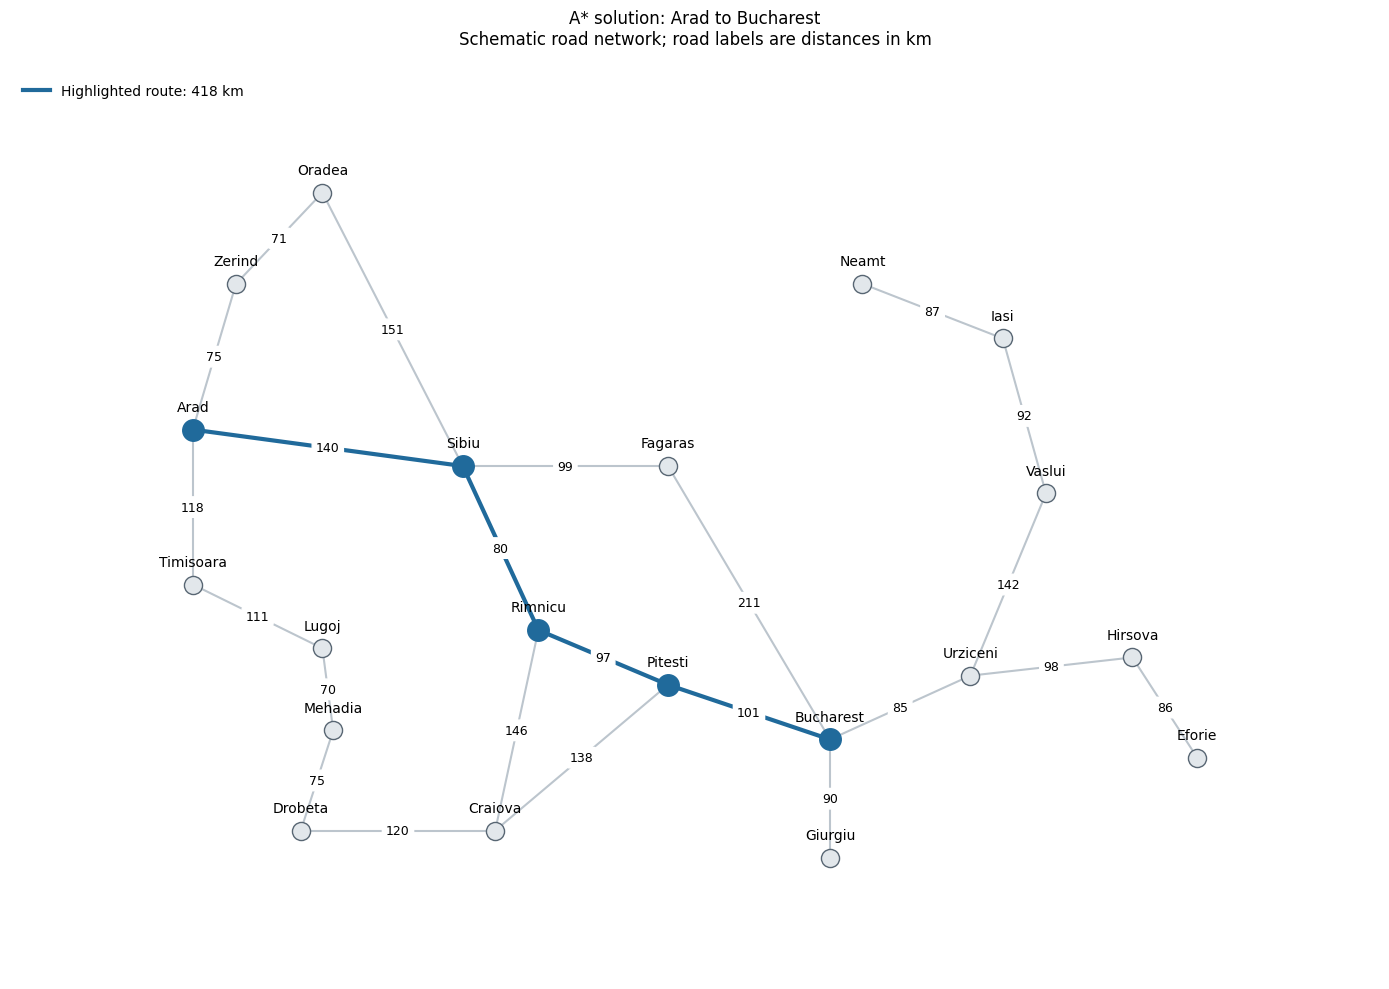

In [13]:
def draw_map_with_path(graph, path, title="Search result"):
    """Show the road network and highlight the chosen route."""
    network = nx.Graph()
    for city in graph.nodes():
        network.add_node(city)
        for neighbor, distance in graph.get(city).items():
            network.add_edge(city, neighbor, weight=distance)

    # These fixed positions follow the slide's diagram, not exact coordinates.
    positions = {
        'Arad': (0, 4.4), 'Zerind': (0.4, 6), 'Oradea': (1.2, 7),
        'Timisoara': (0, 2.7), 'Lugoj': (1.2, 2), 'Mehadia': (1.3, 1.1),
        'Drobeta': (1, 0), 'Craiova': (2.8, 0), 'Rimnicu': (3.2, 2.2),
        'Sibiu': (2.5, 4), 'Fagaras': (4.4, 4), 'Pitesti': (4.4, 1.6),
        'Bucharest': (5.9, 1), 'Giurgiu': (5.9, -0.3), 'Urziceni': (7.2, 1.7),
        'Hirsova': (8.7, 1.9), 'Eforie': (9.3, 0.8), 'Vaslui': (7.9, 3.7),
        'Iasi': (7.5, 5.4), 'Neamt': (6.2, 6)
    }
    # The same function can still draw other small graphs.
    if set(network.nodes) != set(positions):
        positions = nx.spring_layout(network, seed=7, weight=None)

    plt.figure(figsize=(14, 10))
    nx.draw_networkx_edges(network, positions, edge_color='#BCC5CD', width=1.5)
    nx.draw_networkx_nodes(network, positions, node_color='#E2E7EB',
                           edgecolors='#586673', node_size=170)

    route_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(network, positions, edgelist=route_edges,
                           edge_color='#206A9B', width=3)
    nx.draw_networkx_nodes(network, positions, nodelist=path,
                           node_color='#206A9B', node_size=240)

    # Put city names just above the dots so they are easy to read.
    label_positions = {city: (x, y + 0.25) for city, (x, y) in positions.items()}
    nx.draw_networkx_labels(network, label_positions, font_size=10)
    distances = nx.get_edge_attributes(network, 'weight')
    nx.draw_networkx_edge_labels(network, positions, edge_labels=distances,
                                font_size=9, rotate=False)

    total_distance = sum(graph.get(a, b) for a, b in route_edges)
    plt.plot([], [], color='#206A9B', linewidth=3,
             label=f'Highlighted route: {total_distance} km')
    plt.legend(loc='upper left', frameon=False)
    plt.title(title + '\nSchematic road network; road labels are distances in km', pad=20)
    plt.margins(0.12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_map_with_path(romania_map, astar_result.solution(),
                   title="A* solution: Arad to Bucharest")


**Q6.** Looking at your plot, briefly explain (2–3 sentences) why the highlighted path is
the cheapest way from Arad to Bucharest even though it visits more cities than the 3-hop
BFS/Greedy path.

**Answer:** The highlighted route costs 140 + 80 + 97 + 101 = 418 km, while the three-road route through Fagaras costs 140 + 99 + 211 = 450 km. Taking one extra road through Rimnicu and Pitesti avoids the long 211 km road from Fagaras to Bucharest and saves 32 km. UCS and A* both found this minimum-distance route; the number of roads alone does not tell me how far I will drive.

---
# Part 2: Graph Theory

The search algorithms in Part 1 all operated on a graph (the Romania road map) without ever
asking questions *about* that graph itself. Part 2 steps back and looks at the graph as a
mathematical object in its own right — the properties search relies on, whether implicitly or
explicitly: how connected is it, does it contain cycles, and what's the cheapest way to link every
node together?

We'll reuse the same `Graph` class and `romania_map` from Part 1.


## 2.1 Degree of a vertex and the Handshake Lemma

The **degree** of a vertex is its number of incident edges. A basic (but useful!) fact about any
undirected graph is the **Handshake Lemma**: the sum of all vertex degrees equals *twice* the
number of edges, because every edge contributes exactly 1 to the degree of each of its two
endpoints.

Implement `degree(graph, v)`, then use it to verify the Handshake Lemma on `romania_map`.


In [14]:
def degree(graph, v):
    """Count how many roads meet this city."""
    return len(graph.get(v))


In [15]:
total_degree = sum(degree(romania_map, v) for v in romania_map.nodes())

# Count the roads separately so this is a real check of the lemma.
edges = set()
for city in romania_map.nodes():
    for neighbor in romania_map.get(city):
        # Sorting makes Arad-Zerind and Zerind-Arad the same road.
        edges.add(tuple(sorted((city, neighbor))))
num_edges = len(edges)

print("Sum of degrees:", total_degree)
print("Number of unique edges:", num_edges)
print("Handshake lemma holds:", total_degree == 2 * num_edges)


Sum of degrees: 46
Number of unique edges: 23
Handshake lemma holds: True


**Q1.** The Handshake Lemma is true for *every* undirected graph, not just this one. In one
or two sentences, explain why summing all the degrees necessarily double-counts each edge.

**Answer:** Each road touches two cities, so it adds one to the degree of each end. Adding all the degrees therefore counts each road twice, which gives 46 degree entries for the map's 23 roads.

## 2.2 Connectivity

A graph is **connected** if there's a path between every pair of vertices. Implement
`is_connected(graph)` by running a BFS/DFS traversal from an arbitrary start vertex and checking
whether it reaches every vertex in the graph.


In [16]:
def is_connected(graph):
    """Check whether one starting vertex can reach all the others."""
    nodes = graph.nodes()
    if not nodes:
        return True

    visited = {nodes[0]}
    frontier = deque([nodes[0]])
    while frontier:
        node = frontier.popleft()
        for neighbor in graph.get(node):
            if neighbor not in visited:
                visited.add(neighbor)
                frontier.append(neighbor)

    return len(visited) == len(nodes)


In [17]:
print("romania_map is connected:", is_connected(romania_map))

# a graph with two separate components, for contrast
disconnected_map = Graph(dict(
    Alpha=dict(Beta=1),
    Gamma=dict(Delta=1)))
print("disconnected_map is connected:", is_connected(disconnected_map))


romania_map is connected: True
disconnected_map is connected: False


**Q2.** Why does it suffice to start the traversal from just *one* arbitrary vertex to test
connectivity, instead of checking reachability starting from every vertex?

**Answer:** If one starting city can reach every other city, then any two cities can reach each other by going through that starting city. This works because the graph is undirected, so every part of that route can also be followed in reverse.

## 2.3 Connected components

When a graph *isn't* fully connected, it breaks into **connected components** — maximal groups of
vertices that can all reach each other. Implement `connected_components(graph)`, returning a list
of sets, one per component.


In [18]:
def connected_components(graph):
    """Collect each separate group of connected vertices."""
    unvisited = set(graph.nodes())
    components = []

    while unvisited:
        start = min(unvisited)  # Use a fixed order for these named vertices.
        unvisited.remove(start)
        component = {start}
        frontier = deque([start])

        while frontier:
            node = frontier.popleft()
            for neighbor in graph.get(node):
                if neighbor in unvisited:
                    unvisited.remove(neighbor)
                    component.add(neighbor)
                    frontier.append(neighbor)

        components.append(component)

    return components


In [19]:
print("Components of disconnected_map:", connected_components(disconnected_map))
print("Components of romania_map (should be just 1):", len(connected_components(romania_map)))


Components of disconnected_map: [{'Alpha', 'Beta'}, {'Delta', 'Gamma'}]
Components of romania_map (should be just 1): 1


**Q3.** How does `connected_components` relate to `is_connected`? Could you implement
`is_connected(graph)` as a one-line call to `connected_components`? What would that line be?

**Answer:** A non-empty graph is connected when all its vertices belong to one connected component. To match the earlier function, which also returns `True` for an empty graph, I can use this one line:

```python
return len(connected_components(graph)) <= 1
```

## 2.4 Cycle detection

Implement `has_cycle(graph)` for an undirected graph using DFS: track each vertex's parent in the
traversal, and report a cycle if you ever reach an already-visited vertex that **isn't** the
current vertex's immediate parent (revisiting the parent is expected — that's just the edge you
came in on — and doesn't count as a cycle).


In [20]:
def has_cycle(graph):
    """Look for a cycle in an undirected graph."""
    visited = set()

    def dfs(node, parent):
        visited.add(node)
        for neighbor in graph.get(node):
            if neighbor not in visited:
                if dfs(neighbor, node):
                    return True
            elif neighbor != parent:
                # We reached an earlier vertex by a different road.
                return True
        return False

    for node in graph.nodes():
        if node not in visited:
            if dfs(node, None):
                return True
    return False


In [21]:
print("romania_map has a cycle:", has_cycle(romania_map))

tree_map = Graph(dict(A=dict(B=1), B=dict(C=1), C=dict(D=1)))
print("a simple chain (tree) has a cycle:", has_cycle(tree_map))


romania_map has a cycle: True
a simple chain (tree) has a cycle: False


**Q4.** Why does the algorithm need to special-case the immediate parent (`neighbor !=
parent`) instead of just reporting a cycle any time it sees an already-visited neighbor?

**Answer:** An undirected road appears in both cities' neighbor lists. If DFS moves from Arad to Zerind, Zerind will list Arad as a neighbor, but that is just the same road leading back, not a cycle. Ignoring the immediate parent prevents this normal return edge from being mistaken for a cycle.

## 2.5 Eulerian circuits

An **Eulerian circuit** is a closed walk that uses **every edge exactly once** and returns to its
starting vertex (think: "can a mail carrier walk down every street exactly once and end up back
home?"). Euler's theorem gives a simple existence test — no searching required: a connected graph
has an Eulerian circuit **if and only if every vertex has even degree**.

Implement `has_eulerian_circuit(graph)` using that theorem (reusing `is_connected` and `degree`
from earlier), then implement **Hierholzer's algorithm** to actually construct one when it exists.


In [22]:
def has_eulerian_circuit(graph):
    """Check the two conditions given in the lab."""
    if not is_connected(graph):
        return False
    for node in graph.nodes():
        if degree(graph, node) % 2 != 0:
            return False
    return True


In [23]:
print("romania_map degrees:", {v: degree(romania_map, v) for v in sorted(romania_map.nodes())})
print("romania_map has an Eulerian circuit:", has_eulerian_circuit(romania_map))

# A small "bowtie" graph (two triangles sharing vertex C) where every vertex has even degree
euler_graph = Graph(dict(
    A=dict(B=1, C=1),
    B=dict(C=1),
    C=dict(D=1, E=1),
    D=dict(E=1)))
print("euler_graph degrees:", {v: degree(euler_graph, v) for v in sorted(euler_graph.nodes())})
print("euler_graph has an Eulerian circuit:", has_eulerian_circuit(euler_graph))


romania_map degrees: {'Arad': 3, 'Bucharest': 4, 'Craiova': 3, 'Drobeta': 2, 'Eforie': 1, 'Fagaras': 2, 'Giurgiu': 1, 'Hirsova': 2, 'Iasi': 2, 'Lugoj': 2, 'Mehadia': 2, 'Neamt': 1, 'Oradea': 2, 'Pitesti': 3, 'Rimnicu': 3, 'Sibiu': 4, 'Timisoara': 2, 'Urziceni': 3, 'Vaslui': 2, 'Zerind': 2}
romania_map has an Eulerian circuit: False
euler_graph degrees: {'A': 2, 'B': 2, 'C': 4, 'D': 2, 'E': 2}
euler_graph has an Eulerian circuit: True


**Q5.** `romania_map` has several vertices with odd degree (check the printed dictionary
above). In plain English, why does even one odd-degree vertex rule out an Eulerian circuit —
what goes wrong if a mail carrier tries to walk every road exactly once and return home?

**Answer:** Whenever the mail carrier enters a city, there must be a different unused road to leave it, so the roads need to form pairs. The starting city also needs a pair for the first departure and final return. An odd degree leaves one road without a partner, so the carrier cannot use every road once and finish where they started.

In [24]:
def find_eulerian_circuit(graph):
    """Follow unused roads, then join the closed parts of the route."""
    if not has_eulerian_circuit(graph):
        return None
    if not graph.nodes():
        return []

    # Copy the lists so the original graph stays the same.
    adj = {v: list(graph.get(v).keys()) for v in graph.nodes()}
    stack = [graph.nodes()[0]]
    circuit = []

    while stack:
        node = stack[-1]
        if adj[node]:
            neighbor = adj[node].pop()
            adj[neighbor].remove(node)  # Remove the same road from the other end.
            stack.append(neighbor)
        else:
            circuit.append(stack.pop())

    return list(reversed(circuit))


In [25]:
euler_circuit = find_eulerian_circuit(euler_graph)
print("Eulerian circuit:", euler_circuit)
print("Edges used:", len(euler_circuit) - 1,
      " (should equal total edges =", sum(degree(euler_graph, v) for v in euler_graph.nodes()) // 2, ")")


Eulerian circuit: ['A', 'C', 'E', 'D', 'C', 'B', 'A']
Edges used: 6  (should equal total edges = 6 )


## 2.6 Hamiltonian circuits

A **Hamiltonian circuit** is a closed walk that visits **every vertex exactly once** before
returning to the start — a very different requirement from Eulerian (edges vs. vertices!). Unlike
Eulerian circuits, there's no simple degree-counting theorem that decides this in general — you
have to search for one, which is exactly why it belongs in an AI course: this is a **constraint
satisfaction / backtracking search** problem, structurally similar to Part 1.

Implement `has_hamiltonian_circuit(graph, start)` with backtracking: extend a path one unvisited
neighbor at a time, and check that the path can close back to `start` once every vertex is used.


In [26]:
def has_hamiltonian_circuit(graph, start=None):
    """Try routes that visit each vertex once and return to the start."""
    nodes = graph.nodes()
    n = len(nodes)
    if n < 3:  # A cycle in this simple graph needs at least three vertices.
        return False
    if start is None:
        start = nodes[0]
    if start not in nodes:
        return False

    def backtrack(path, visited):
        if len(path) == n:
            return start in graph.get(path[-1])

        for neighbor in graph.get(path[-1]):
            if neighbor not in visited:
                path.append(neighbor)
                visited.add(neighbor)
                if backtrack(path, visited):
                    return True

                # This choice failed, so undo it and try another neighbor.
                path.pop()
                visited.remove(neighbor)
        return False

    return backtrack([start], {start})


In [27]:
print("romania_map has a Hamiltonian circuit:", has_hamiltonian_circuit(romania_map, "Arad"))

# A complete graph on 4 vertices: every pair connected, so a Hamiltonian circuit always exists
k4 = Graph(dict(A=dict(B=1, C=1, D=1), B=dict(C=1, D=1), C=dict(D=1)))
print("K4 has a Hamiltonian circuit:", has_hamiltonian_circuit(k4))

# A star graph: one center connected to several leaves, no edges between leaves
star = Graph(dict(Center=dict(Leaf1=1, Leaf2=1, Leaf3=1, Leaf4=1)))
print("star graph has a Hamiltonian circuit:", has_hamiltonian_circuit(star))


romania_map has a Hamiltonian circuit: False
K4 has a Hamiltonian circuit: True
star graph has a Hamiltonian circuit: False


**Q6.** `romania_map` has no Hamiltonian circuit. Looking back at the degree printout from
Q5, several cities (Eforie, Giurgiu, Neamt) have degree 1. Explain why **any** vertex with degree 1
immediately rules out a Hamiltonian circuit — and contrast this with why the star graph above also
fails, even though its leaves have degree 1 too.

**Answer:** A city on a Hamiltonian circuit needs one road to enter and a different road to leave, so it must have degree at least two. Eforie, Giurgiu, and Neamt each have only one road, which rules out a circuit through every city in Romania. The star graph fails for the same reason: each leaf has one road, and travelling between leaves would also force repeated visits to the center.

---
# Wrap-up

**Reflection question.** Part 1's search algorithms and Part 2's Hamiltonian circuit check
(2.6) are both, structurally, backtracking searches over the same kind of state space — yet
Eulerian circuits (2.5) needed no search at all, just a degree count. In 3–5 sentences: what is it
about the Eulerian problem that admits a simple, efficient theorem, while the Hamiltonian problem
does not? Why does that same reasoning explain why UCS/A\* on Part 1's road map is efficient, while
brute-force Hamiltonian search only barely finished quickly for a graph this small?


*(open-ended reflection — see prompt above)*

**Answer:** An Eulerian circuit allows a city to be visited again, so roads can be joined into a tour when the graph is connected and all degrees are even. We can check this with a traversal and degree counts instead of trying many possible tours. A Hamiltonian circuit cannot repeat a city, so its search must remember both the current city and which cities have already been used, creating many possible visiting orders. UCS and A* use priority queues rather than recursive backtracking, and they can discard more expensive routes to the same city because earlier visits do not restrict the remaining route. Romania's dead ends can make Hamiltonian search fail quickly, but other graphs may need far more trial routes, and there is no known equally simple general test based only on degree counts.

## Sources and run note

- **Lab slides:** `Lab2_AI4E.pptx.pdf`, especially slides 3 and 4 for the Romania road diagram and distances.
- **Supplied notebook:** `cuwatwem_Search_and_graph_theory.ipynb` for the classes, road data, heuristic values, questions, and test graphs. The supplied classes are unchanged.


To run the notebook locally, select a Python 3 kernel and choose **Restart Kernel and Run All**. The required packages are `networkx`, `matplotlib`, and a Jupyter/IPython environment.
